# Adım 2 — Veri Keşfi ve Görselleştirme (EDA)

**EDA = Exploratory Data Analysis.** Modele geçmeden önce veriyi *gözle* anlamak. Her grafik
bir proje sorusuna cevap verir:

| Grafik | Cevapladığı soru |
|---|---|
| A. Sınıf dağılımı | Veri ne kadar dengesiz? (→ `class_weight`, StratifiedKFold) |
| B. Sınıfa göre boxplot | Hangi feature hangi atağı ayırıyor? (→ feature importance ön-provası) |
| C. Intensity-tepki | Yoğunluk knob'ları anlamlı/monoton mu? (→ detection-vs-intensity eğrisi) |
| D. PCA saçılım | Sınıflar feature uzayında ayrışıyor mu? (→ model kolay mı zor mu) |
| E. Korelasyon | Feature'lar birbirini tekrar ediyor mu? |

> Renkler CVD (renk körlüğü) güvenli bir paletten, sabit sınıf→renk eşlemesiyle.
> Üretilen grafikler `figs/` altına da kaydedilir.

In [1]:
# --- Kütüphaneler ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt                       # çizim
from matplotlib.colors import LinearSegmentedColormap # kendi renk skalamızı yapmak için (heatmap)
from pathlib import Path
from sklearn.preprocessing import StandardScaler      # PCA öncesi ölçekleme
from sklearn.decomposition import PCA                 # boyut indirgeme (13D -> 2D görselleştirme)

# --- veri + çıktı klasörü (repo kökünden veya notebook klasöründen açılsa da çalışır) ---
cands = [
    ("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv", "my-work/day5-10072026-detector"),
    ("../day3-4-08072026-09072026-dataset/out/dataset.csv", "."),
]
DATA, BASE = next(((Path(d), Path(b)) for d, b in cands if Path(d).exists()), (None, None))
assert DATA is not None, "dataset.csv bulunamadi"
df = pd.read_csv(DATA)
FIGDIR = BASE / "figs"; FIGDIR.mkdir(exist_ok=True)   # grafikleri buraya PNG olarak da kaydedeceğiz
print("Yuklendi:", df.shape, "| figurler:", FIGDIR)

# --- sabit sınıf sırası + CVD-güvenli renk eşlemesi (kural: renk varlığı takip eder, tüm grafiklerde aynı) ---
CLASS_ORDER = ["normal", "dos", "ddos", "greyhole", "blackhole"]
COLORS = {
    "normal":    "#2a78d6",  # blue
    "dos":       "#1baf7a",  # aqua
    "ddos":      "#eda100",  # yellow
    "greyhole":  "#008300",  # green  (yeni atağımız)
    "blackhole": "#4a3aa7",  # violet
}
# NOT: telemetry_throughput_mbps EDA'da sabit (zero-variance) cikti -> feature setinden cikarildi
#  Asagidaki liste modelin gordugu 11 feature'i tutar.
FEATURES = ["n_flows", "total_throughput_mbps", "max_flow_throughput_mbps", "max_flow_txpackets",
            "flow_concentration", "delivery_ratio", "overall_loss_ratio", "monitor_owd_ms",
            "monitor_pdv_ms", "mean_owd_ms", "mean_pdv_ms"]

# --- ink token'ları (yazı/ızgara renkleri) + genel stil: ince marklar, geri planda soluk ızgara ---
PRIMARY, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({                                  # tüm grafiklere uygulanan varsayılan stil
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": PRIMARY, "axes.labelcolor": SECONDARY, "axes.titlecolor": PRIMARY,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": AXIS,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
})

def style_ax(ax):                                      # her eksene uygulanan ortak sadeleştirme
    ax.spines["top"].set_visible(False)                # üst/sağ çerçeve çizgilerini kaldır
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)  # sadece yatay ızgara, soluk
    ax.set_axisbelow(True)                             # ızgara verinin arkasında kalsın
    return ax
print("Stil + palet hazir.")

Yuklendi: (285, 19) | figurler: figs
Stil + palet hazir.


## A. Sınıf dağılımı — ne kadar dengesiz?

Çubuk uzunluğu = her sınıftaki koşu sayısı. **greyhole 90 vs blackhole 10** uçurumu, neden
`class_weight='balanced'` ve StratifiedKFold kullanacağımızın görsel gerekçesi.

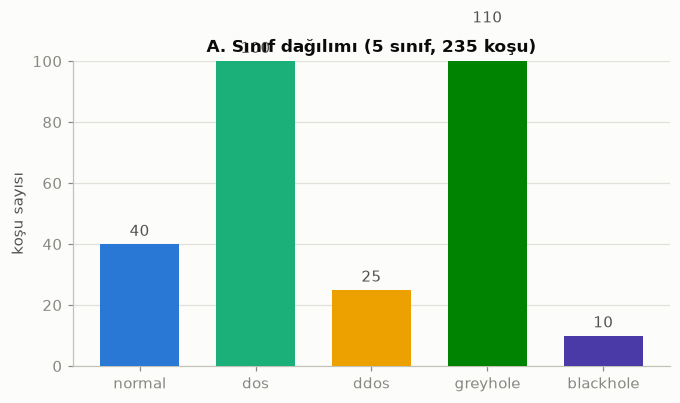

Binary: attack 245 / normal 40


In [2]:
# her sınıftan kaç koşu — CLASS_ORDER sırasına diz (.reindex)
counts = df["label_class"].value_counts().reindex(CLASS_ORDER)
fig, ax = plt.subplots(figsize=(7, 3.6))               # tek grafik (fig) + eksen (ax)
bars = ax.bar(CLASS_ORDER, counts.values,
              color=[COLORS[c] for c in CLASS_ORDER],   # her çubuk kendi sınıf rengiyle
              width=0.68, zorder=3)
for b, v in zip(bars, counts.values):                  # değeri çubuğun üstüne yaz (direct label)
    ax.text(b.get_x()+b.get_width()/2, v+1.5, str(v), ha="center", va="bottom",
            fontsize=10, color=SECONDARY)
style_ax(ax)
ax.set_ylabel("koşu sayısı")
ax.set_ylim(0, 100)  # sabit üst sınır: en kalabalık sınıf (greyhole=90) rahat sığsın; sabit
                      # olması, koşu sayısı değişse bile grafiği tekrar üretince eksenin
                      # kaymamasını sağlar (görsel kıyaslanabilirlik)
ax.set_title("A. Sınıf dağılımı (5 sınıf, 235 koşu)")
fig.savefig(FIGDIR/"A-sinif-dagilimi.png"); plt.show() # PNG kaydet + notebook'ta göster
print("Binary: attack", (df.label_binary=='attack').sum(), "/ normal", (df.label_binary=='normal').sum())

## B. Sınıfa göre boxplot — hangi feature hangi atağı ayırıyor?

Her kutu bir sınıfın o feature'daki dağılımı (orta çizgi = medyan, kutu = %25–75). Sınıfların
kutuları **ayrık** ise o feature ayırıcıdır. Beklenti:
- `delivery_ratio`: normal/dos yukarıda (~1), grey aşağı iner, blackhole 0.
- `n_flows`: ddos yüksek (çok flooder), diğerleri düşük.
- `monitor_owd_ms`: blackhole'da **yok** (yol kapalı = ölçülemez); grafikte "N/A" olarak işaretli.

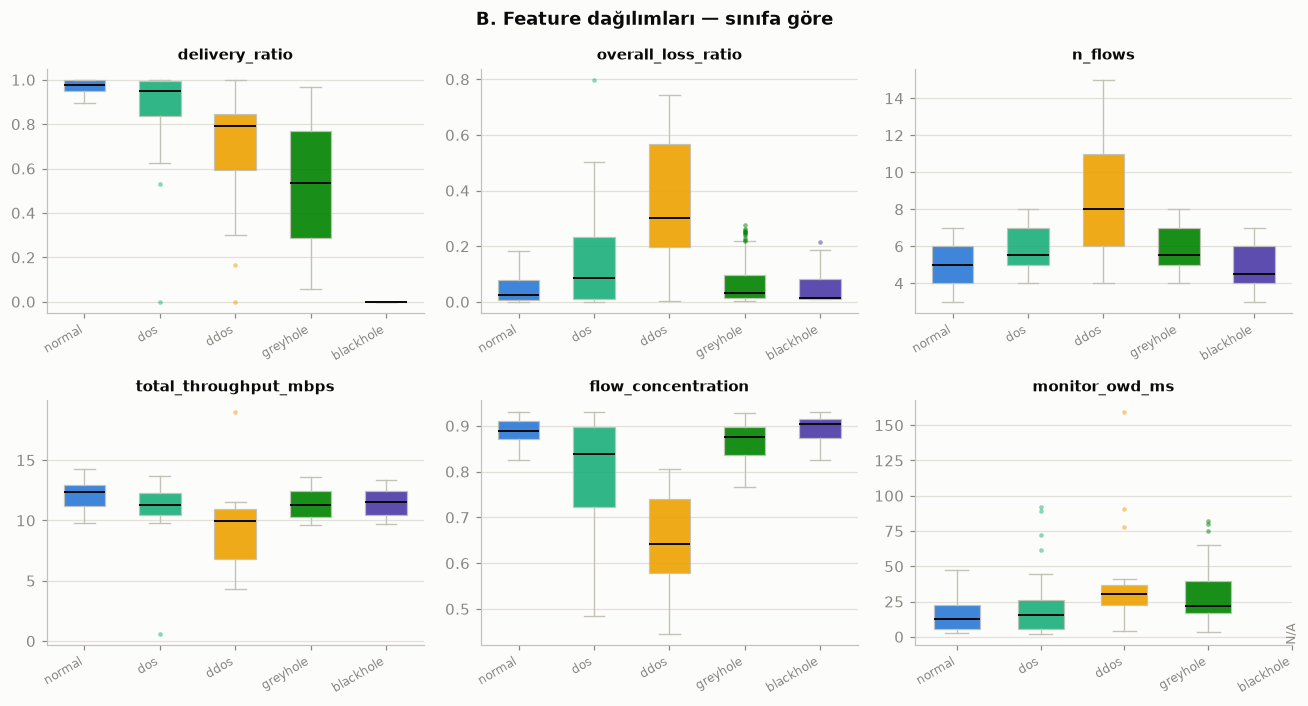

In [3]:
feats_box = ["delivery_ratio", "overall_loss_ratio", "n_flows",
             "total_throughput_mbps", "flow_concentration", "monitor_owd_ms"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))      # 2x3 küçük-çoklu ızgara (6 feature)
for ax, feat in zip(axes.ravel(), feats_box):          # .ravel(): 2x3'ü tek listeye düzleştir
    for i, c in enumerate(CLASS_ORDER):                # her sınıf için bir kutu (x konumu = i)
        vals = df.loc[df.label_class == c, feat].dropna().values   # o sınıfın değerleri (NaN'ları at)
        if len(vals) == 0:                             # blackhole'da control_owd = boş -> kutu çizme
            ax.text(i, ax.get_ylim()[0], "N/A", ha="center", va="bottom",
                    fontsize=8, color=MUTED, rotation=90)
            continue
        bp = ax.boxplot(vals, positions=[i], widths=0.55, patch_artist=True,  # patch_artist: kutuyu boyayabil
                        medianprops=dict(color=PRIMARY, linewidth=1.3),
                        flierprops=dict(marker="o", markersize=3, markerfacecolor=COLORS[c],
                                        markeredgecolor="none", alpha=0.5))    # aykırı değer noktaları
        for box in bp["boxes"]:
            box.set(facecolor=COLORS[c], edgecolor=AXIS, linewidth=0.8, alpha=0.9)  # kutuyu sınıf rengiyle boya
        for w in bp["whiskers"] + bp["caps"]:
            w.set(color=AXIS, linewidth=0.9)
    style_ax(ax)
    ax.set_xticks(range(len(CLASS_ORDER)))             # x eksenine sınıf adlarını yaz (kimlik = etiket)
    ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right", fontsize=8)
    ax.set_title(feat, fontsize=10)
fig.suptitle("B. Feature dağılımları — sınıfa göre", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGDIR/"B-boxplot-by-class.png"); plt.show()

## C. Intensity-tepki eğrileri — knob'lar anlamlı mı?

Her atağın yoğunluk knob'u artarken bir feature'ın nasıl değiştiğini gösterir (ortalama ± koşular).
Düzgün/monoton bir eğri, detection-vs-intensity eğrisinin neden çalışacağının kanıtı:
- **greyhole:** `delivery_ratio` ≈ (1 − p) olmalı (p arttıkça teslim düşer).
- **dos:** `throughput` flood hızıyla artmalı.
- **ddos:** `n_flows` saldırgan sayısıyla artmalı.

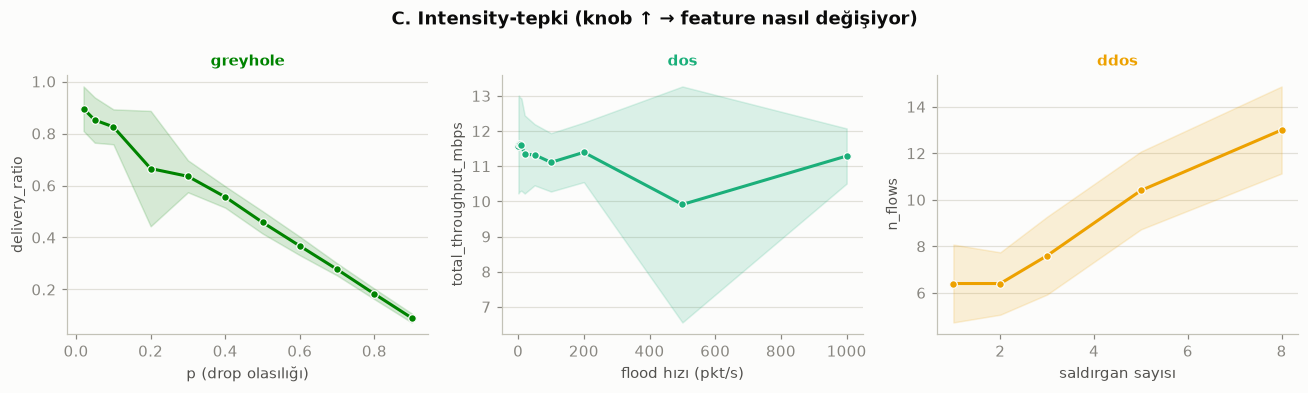

In [4]:
# (senaryo, çizilecek feature, x-ekseni etiketi) üçlüleri
panels = [
    ("greyhole", "delivery_ratio",        "p (drop olasılığı)"),
    ("dos",      "total_throughput_mbps",  "flood hızı (pkt/s)"),
    ("ddos",     "n_flows",                "saldırgan sayısı"),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))      # 1x3 panel (her atak bir panel)
for ax, (scen, feat, xlab) in zip(axes, panels):
    sub = df[df.label_class == scen]                   # sadece o senaryonun koşuları
    # aynı intensity'deki koşuları grupla -> ortalama ve std (yayılım)
    g = sub.groupby("intensity")[feat].agg(["mean", "std"]).reset_index()
    ax.plot(g["intensity"], g["mean"], "-o", color=COLORS[scen], linewidth=2,   # ortalama çizgi + nokta
            markersize=5, markeredgecolor=SURFACE, markeredgewidth=0.8, zorder=3)
    ax.fill_between(g["intensity"], g["mean"]-g["std"].fillna(0), g["mean"]+g["std"].fillna(0),
                    color=COLORS[scen], alpha=0.15, zorder=1)   # ±std gölgesi (koşular arası yayılım)
    style_ax(ax)
    ax.set_xlabel(xlab); ax.set_ylabel(feat, fontsize=9)
    ax.set_title(scen, fontsize=10, color=COLORS[scen])
fig.suptitle("C. Intensity-tepki (knob ↑ → feature nasıl değişiyor)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGDIR/"C-intensity-tepki.png"); plt.show()

## D. PCA saçılım — sınıflar ayrışıyor mu?

13 feature'ı (11 + `monitor_missing`) 2 boyuta indirip (PCA) sınıfa göre renklendiriyoruz.
Kümeler **ayrık** ise model kolay iş yapacak; iç içe ise zor. PCA öncesi feature'lar
standardize edilir (farklı ölçekler eşitlensin). Not: PCA sadece *görselleştirme* için;
modeli RandomForest ile kuracağız (o standardize istemez).

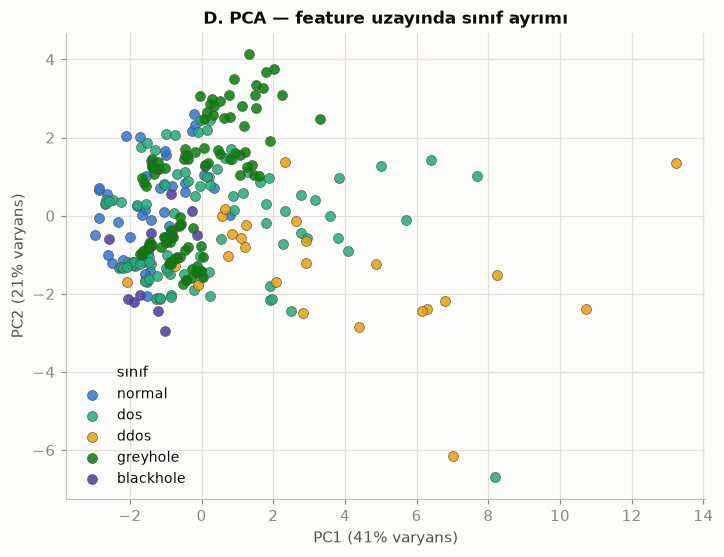

Iki bilesen toplam varyansin %62'ini acikliyor.


In [5]:
# X'i kur (Adım 1 ile aynı mantık): feature'lar + monitor_missing indicator + NaN->0
Xp = df[FEATURES].copy()
# monitor_owd_ms bazı koşularda NaN: blackhole'da yol tamamen kapalı olduğu için kontrol paketi
# hiç geri dönmüyor, ölçülemiyor. Bu "eksiklik" tesadüfi değil, atağın kendisi hakkında bilgi
# taşıyor (missingness-is-informative) -> onu 0/1 ayrı bir feature olarak saklıyoruz, yoksa
# fillna(0.0) ile normal bir "0 ms gecikme" ile karışıp bilgi kaybolurdu.
Xp["monitor_missing"] = Xp["monitor_owd_ms"].isna().astype(int)
Xp = Xp.fillna(0.0)  # PCA/StandardScaler NaN kabul etmez; monitor_missing indicator sayesinde
                      # 0 ile doldurmak güvenli (eksik olduğu bilgisi ayrı feature'da korunuyor)

Xs = StandardScaler().fit_transform(Xp)                # her feature'ı ort=0, std=1'e çek (PCA için şart)
pca = PCA(n_components=2, random_state=0)              # en çok varyansı taşıyan 2 ekseni bul
Z = pca.fit_transform(Xs)                              # her koşuyu 2 sayıya (PC1, PC2) indir
ev = pca.explained_variance_ratio_ * 100              # bu 2 eksen verinin yüzde kaçını açıklıyor

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for c in CLASS_ORDER:                                  # her sınıfı ayrı renk + legend etiketiyle çiz
    m = (df.label_class == c).values                   # o sınıfın satırları (boolean maske)
    ax.scatter(Z[m, 0], Z[m, 1], s=42, color=COLORS[c], label=c,
               edgecolor=SECONDARY, linewidth=0.5, alpha=0.85, zorder=3)  # nokta kenarı: düşük-kontrast rengi ayırır
style_ax(ax); ax.grid(True, color=GRID, linewidth=0.8)
ax.set_xlabel(f"PC1 ({ev[0]:.0f}% varyans)")
ax.set_ylabel(f"PC2 ({ev[1]:.0f}% varyans)")
ax.set_title("D. PCA — feature uzayında sınıf ayrımı")
ax.legend(frameon=False, fontsize=9, title="sınıf")    # legend: kimlik renk-tek-başına kalmasın
fig.savefig(FIGDIR/"D-pca-scatter.png"); plt.show()
print(f"Iki bilesen toplam varyansin %{ev.sum():.0f}'ini acikliyor.")

## E. Korelasyon ısı haritası — feature'lar birbirini tekrar ediyor mu?

İki feature'ın birlikte değişme derecesi (+1 mavi = birlikte artar, −1 kırmızı = ters, 0 gri).
Çok yüksek korelasyonlu çiftler *redundant* olabilir (biri diğerinin bilgisini taşır) — model
ve yorum için bilmek faydalı.

> **EDA bulgusu:** İlk çizimde `telemetry_throughput_mbps` satırı **boş** (tüm korelasyonlar NaN)
> çıkmıştı — sebebi **sıfır varyans** (tüm koşularda `0.3029...`, sabit). Sabit feature ayrım
> bilgisi taşımaz; bu yüzden feature setinden çıkardık. Aşağıdaki harita 11 feature'ı gösterir.

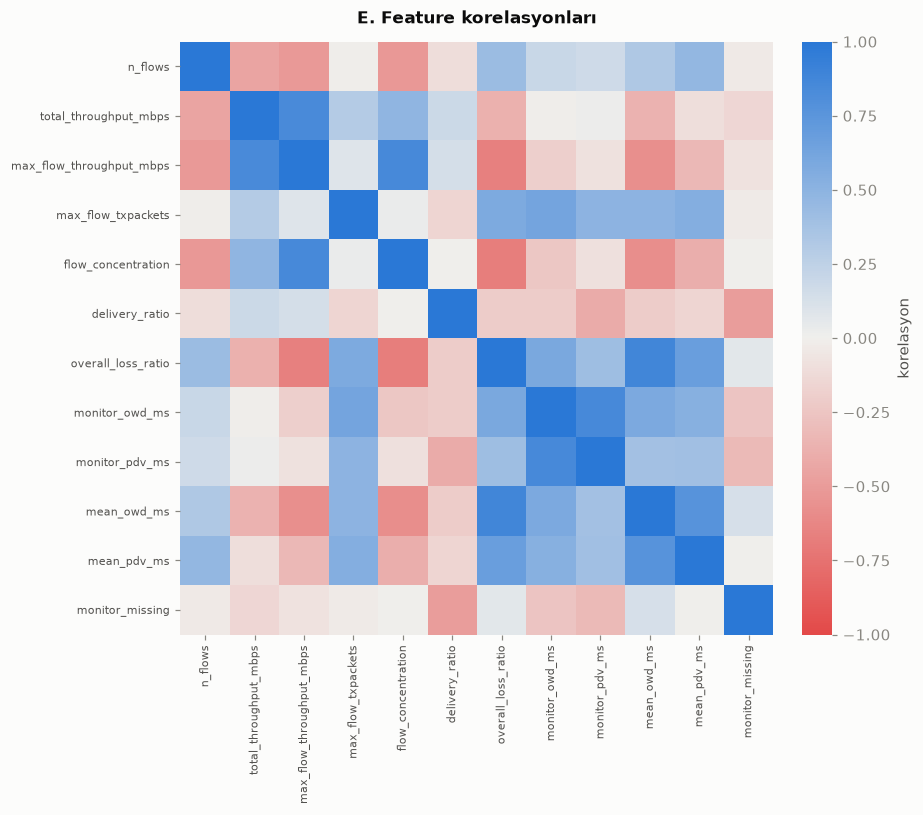

In [6]:
# NOT: Xp, D hücresinde kurulan haliyle kullanılıyor -> control_owd/pdv NaN'ları 0'la doldurulmuş
# (+ monitor_missing indicator eklenmiş). Yani blackhole satırlarında "kontrol paketi hiç
# dönmedi" durumu burada 0 ms gibi görünüyor; bu, control_owd/pdv'nin diğer feature'larla
# korelasyonunu hafifçe çarpıtabilir (gerçek "eksik" ile gerçek "0" aynı görünüyor). Ham/eksiksiz
# koşularda bu feature'ları yorumlarken B panelindeki boxplot'a (NaN'ları dropna yapan) güvenmek
# daha doğru; burası genel redundancy taraması için yeterli.
corr = Xp.corr()                                   # feature'lar arası korelasyon matrisi (-1..+1)
# kendi renk skalamız: kırmızı(-1) ↔ gri(0) ↔ mavi(+1) (diverging: iki kutup + nötr orta)
div = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr.values, cmap=div, vmin=-1, vmax=1) # matrisi renkli kare olarak çiz
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7, color=SECONDARY)
ax.set_yticklabels(corr.columns, fontsize=7, color=SECONDARY)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04) # yan renk skalası (hangi renk hangi değer)
cb.set_label("korelasyon", color=SECONDARY); cb.outline.set_visible(False)
ax.set_title("E. Feature korelasyonları", pad=12)
fig.savefig(FIGDIR/"E-korelasyon.png"); plt.show()

## Özet — ne öğrendik?

- **Dengesizlik** gerçek (90→10) → `class_weight` + StratifiedKFold gerekli.
- **delivery_ratio** teslim ataklarını (grey/blackhole), **n_flows** ddos'u, **throughput/txpackets**
  flood'u ayırıyor → RandomForest'ın farklı bölgelerde farklı feature kullanması mantıklı.
- **Intensity eğrileri monoton** → knob'lar sağlam, detection-vs-intensity eğrisi anlamlı olacak.
- **PCA**'da sınıflar büyük ölçüde ayrık; beklenen zor bölgeler: dos↔ddos ve grey(yüksek p)↔blackhole.

**Sonraki adım (Adım 3):** binary detektör — StratifiedKFold + F1 + confusion matrix + baseline.